In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('./data/cleaned_disease_data.csv')
df.columns

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Alcohol',
       'Hepatitis_B', 'BMI', 'Polio', 'Diphtheria', 'HIV_AIDS', 'GDP',
       'thinness _1_19_years', 'thinness_5_9_years', 'Iso_code', 'Region',
       'Region_encoded', 'Schooling', 'Measles'],
      dtype='object')

In [3]:
X = df.drop(['Life_expectancy', 'Year', 'Iso_code', 'Region', 'Country','HIV_AIDS'], axis =1)
y = df['Life_expectancy']

In [4]:
X.head()

,Status,Alcohol,Hepatitis_B,BMI,Polio,Diphtheria,GDP,thinness _1_19_years,thinness_5_9_years,Region_encoded,Schooling,Measles
0,0,0.01,62.0,12.2,24.0,24.0,114.560000,2.3,2.5,1,1.264052,27.0
1,0,0.01,63.0,12.6,35.0,33.0,117.496980,2.1,2.4,1,1.315551,37.0
2,0,0.01,64.0,13.0,36.0,36.0,187.845950,19.9,2.2,1,1.367049,35.0
3,0,0.01,65.0,13.4,41.0,41.0,198.728544,19.7,19.9,1,1.418548,39.0
4,0,0.02,95.0,13.8,95.0,95.0,219.141353,19.5,19.7,1,1.470046,48.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_reg = RandomForestRegressor(max_depth=7, random_state=0)
rf_reg.fit(X_train,y_train)
rf_reg.score(X_train,y_train), rf_reg.score(X_test,y_test)

(0.9203970859936356, 0.8811742502029519)

In [7]:
y_pred = rf_reg.predict(X_test)

rf_reg_acc = r2_score(y_test, y_pred)
print(rf_reg_acc)

0.8811742502029519


In [8]:
# 5. 특성 중요도 시각화
rf_reg.feature_importances_

feat_impt_ser = pd.Series(
    rf_reg.feature_importances_, index=X.columns
).sort_values(ascending=False)
print(feat_impt_ser)

Region_encoded          0.562229
Schooling               0.088740
Measles                 0.057681
GDP                     0.049081
Status                  0.047409
thinness_5_9_years      0.039375
BMI                     0.038327
Polio                   0.028037
Alcohol                 0.027865
Hepatitis_B             0.027164
thinness _1_19_years    0.018392
Diphtheria              0.015702
dtype: float64


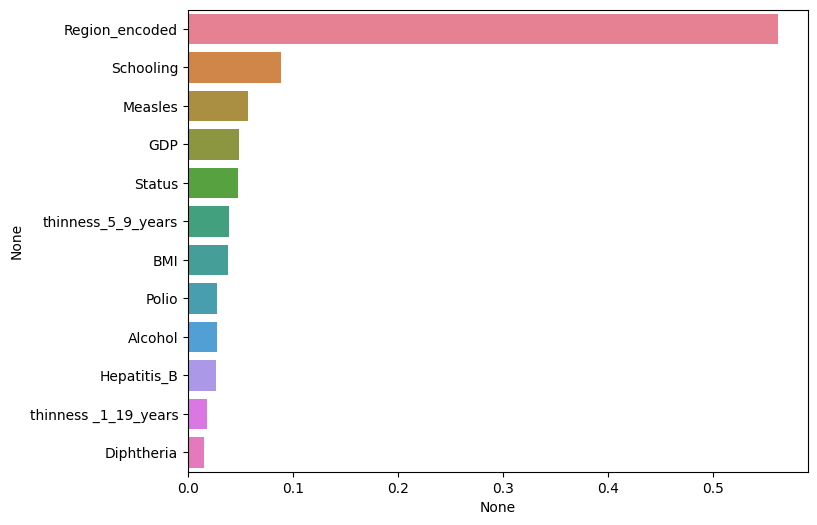

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    x= feat_impt_ser,
    y = feat_impt_ser.index,
    hue = feat_impt_ser.index
)
plt.show()

In [10]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': range(95, 105),
#     'max_depth': range(8 , 12),
#     'min_samples_split': [2, 3, 4],
#     'min_samples_leaf': [1, 2, 3],
#     'max_features': ['sqrt', None]
# }

# grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')


In [11]:
# grid_search.fit(X_train,y_train)

In [12]:
# grid_search.best_params_

In [13]:
# grid_search.best_score_

In [14]:
# param_grid_v2 = {
#     'max_depth': [11, 15, 20, None],
#     'n_estimators': [ 200, 300, 500],
#     'max_features': [None, 'sqrt'], # 이미 None이 좋다고 나왔으니 고정하거나 'sqrt' 정도만 추가
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }

In [15]:
# grid_search_v2 = GridSearchCV(RandomForestRegressor(), param_grid_v2, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

In [16]:
# grid_search_v2.fit(X_train,y_train)

In [17]:
# grid_search_v2.best_params_

In [18]:
# grid_search_v2.best_score_

In [19]:
# gs_optimized_rf_reg= grid_search_v2.best_estimator_

In [20]:
# gs_optimized_rf_reg.fit(X_train, y_train)

In [21]:
# gs_optimized_rf_reg.score(X_train,y_train), gs_optimized_rf_reg.score(X_test,y_test)

In [22]:
# # 5. 특성 중요도 시각화
# gs_optimized_rf_reg.feature_importances_

# feat_impt_ser = pd.Series(
#     gs_optimized_rf_reg.feature_importances_, index=X.columns
# ).sort_values(ascending=False)
# print(feat_impt_ser)

In [23]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8,6))
# sns.barplot(
#     x= feat_impt_ser,
#     y = feat_impt_ser.index,
#     hue = feat_impt_ser.index
# )
# plt.show()

### Optuna

In [24]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # 1. 탐색할 파라미터 범위 정의 (Grid보다 훨씬 넓게 설정 가능!)
    param = {
        # n_estimators: 100 근처에서 더 넓게 탐색
        'n_estimators': trial.suggest_int('n_estimators', 50, 500), 
        
        # max_depth: 8~20까지 확장 (아까 20이 나왔었으므로)
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        
        # 정수형 파라미터들
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        
        # 범주형 파라미터
        'max_features': trial.suggest_categorical('max_features', ['sqrt', None])
    }

    # 2. 모델 설정
    model = RandomForestRegressor(**param, n_jobs=-1, random_state=42)
    
    # 3. 교차 검증 (CV) - MSE를 평가지표로 사용
    # neg_mean_squared_error를 사용하므로 score가 클수록(0에 가까울수록) 좋은 것임
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    
    return score

# 4. 학습 최적화 실행
study = optuna.create_study(direction='maximize') # 점수가 커지는 방향으로
study.optimize(objective, n_trials=50) # 50번의 똑똑한 시도

# 5. 결과 출력
print(f"최적의 MSE 점수: {-study.best_value}") # 마이너스 떼고 출력
print(f"최적의 파라미터: {study.best_params}")

[I 2026-02-10 14:22:58,135] A new study created in memory with name: no-name-909298d4-409e-406d-93f0-8bd48b20b423
[I 2026-02-10 14:23:00,828] Trial 0 finished with value: -11.761093773396379 and parameters: {'n_estimators': 289, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: -11.761093773396379.
[I 2026-02-10 14:23:02,830] Trial 1 finished with value: -10.357533611181914 and parameters: {'n_estimators': 211, 'max_depth': 21, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: -10.357533611181914.
[I 2026-02-10 14:23:03,758] Trial 2 finished with value: -9.517369693926337 and parameters: {'n_estimators': 91, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 2 with value: -9.517369693926337.
[I 2026-02-10 14:23:07,477] Trial 3 finished with value: -9.61337927693 and parameters: {'n_estimators': 410, 'max_depth': 12, 'min_s

최적의 MSE 점수: 7.845906198723656
최적의 파라미터: {'n_estimators': 225, 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}


In [25]:
# 1. Optuna가 찾은 최적 파라미터로 모델 생성
best_params = study.best_params
final_model = RandomForestRegressor(**best_params, random_state=42)

# 2. 전체 학습 데이터로 최종 학습
final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",225
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",28
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [26]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = final_model.predict(X_test)

# 성능 지표 계산
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"최종 R2 Score: {r2:.4f}")
print(f"최종 RMSE: {rmse:.4f}")

최종 R2 Score: 0.9212
최종 RMSE: 2.5962


In [27]:
final_model.feature_importances_

feat_impt_ser = pd.Series(
    final_model.feature_importances_, index=X.columns
).sort_values(ascending=False)
print(feat_impt_ser)

Region_encoded          0.516169
Schooling               0.093884
Measles                 0.055519
GDP                     0.053435
BMI                     0.049659
thinness_5_9_years      0.045773
Status                  0.042528
Alcohol                 0.037265
Polio                   0.031793
thinness _1_19_years    0.026203
Hepatitis_B             0.024675
Diphtheria              0.023097
dtype: float64


In [28]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_squared_log_error, root_mean_squared_log_error, r2_score
def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    msle = mean_squared_log_error(y_true, y_pred)
    rmsle = root_mean_squared_log_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MSLE': msle, 'RMSLE': rmsle, 'R2': r2}, name=name)

In [29]:
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

train_metrics = evaluate_model(y_train, y_train_pred, 'Train')
test_metrics = evaluate_model(y_test, y_test_pred, 'Test')

In [31]:
metrics_df = pd.DataFrame([train_metrics, test_metrics])
print(metrics_df.round(4))

          MSE    RMSE     MAE    MSLE   RMSLE      R2
Train  1.0046  1.0023  0.6359  0.0003  0.0166  0.9887
Test   6.7402  2.5962  1.7343  0.0016  0.0405  0.9212


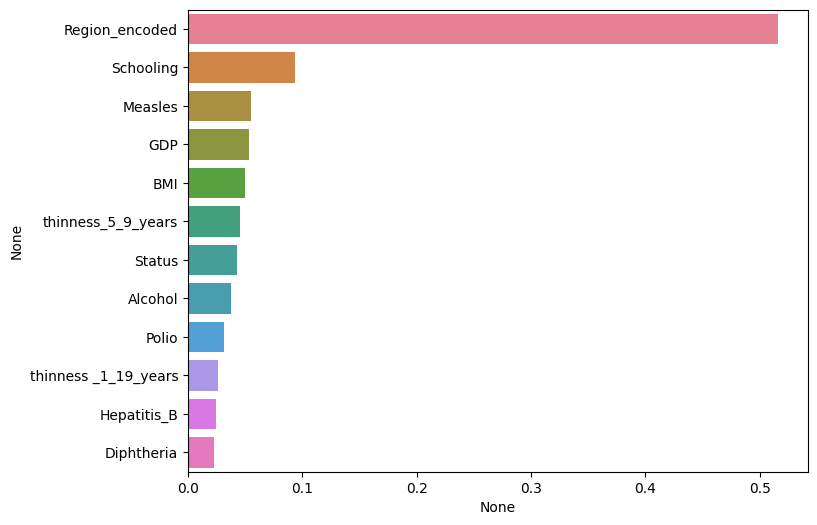

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    x= feat_impt_ser,
    y = feat_impt_ser.index,
    hue = feat_impt_ser.index
)

plt.show()